# Лабораторная работа №3: Трансформеры

## Цель
Познакомиться с архитектурой Transformer и её применением для задач NLP (классификация текста, машинный перевод).

## Теория
- Архитектура Transformer: encoder-decoder, self-attention.
- Различия BERT и GPT.

## Задания
1. Использовать BERT (через HuggingFace).
2. Провести fine-tuning на IMDb dataset.
3. Сравнить результаты с baseline (логистическая регрессия + TF-IDF).
4. Оценить точность и построить confusion matrix.

## Вопросы
1. Зачем нужен positional encoding?
2. В чём отличие encoder-only и decoder-only моделей?
3. Почему трансформеры лучше RNN в NLP?

## Отчёт
- Краткое описание выбранной задачи.
- Результаты fine-tuning.
- Сравнение с baseline.
- Ответы на вопросы.

### Краткое описание выбранной задачи
Задача состоит в бинарной классификации отзывов на фильмы (IMDb dataset) на положительные и отрицательные. Используются два подхода:
1. Baseline: Классический ML подход (TF-IDF векторизация + Логистическая регрессия).
2. Transformer: Fine-tuning предобученной модели BERT (`bert-base-uncased`).

In [3]:
!pip install datasets

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.1/75.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.4/242.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.6/221.6 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.3/377.3 kB 32.2 MB/s eta 0:00:00


In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [2]:
torch.cuda.is_available()

True

In [4]:
dataset = load_dataset("imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

## Baseline: Логистическая регрессия + TF-IDF

In [5]:
# Подготовка данных для sklearn
train_texts = dataset['train']['text']
train_labels = dataset['train']['label']
test_texts = dataset['test']['text']
test_labels = dataset['test']['label']

# TF-IDF векторизация
print("Векторизация TF-IDF...")
vectorizer = TfidfVectorizer(max_features=10000)
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

# Обучение логистической регрессии
print("Обучение Baseline модели...")
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, train_labels)

# Предсказание
y_pred_baseline = clf.predict(X_test_tfidf)

# Оценка Baseline
accuracy_baseline = accuracy_score(test_labels, y_pred_baseline)
print(f'Baseline Accuracy: {accuracy_baseline:.4f}')
print(classification_report(test_labels, y_pred_baseline))

Векторизация TF-IDF...
Обучение Baseline модели...
Baseline Accuracy: 0.8837
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## Fine-tuning BERT

In [6]:
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Используем подмножество данных для ускорения обучения в рамках лабораторной работы
# (полное обучение занимает много времени)
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
small_test_dataset = dataset["test"].shuffle(seed=42).select(range(500))

print("Токенизация данных...")
tokenized_train = small_train_dataset.map(tokenize_function, batched=True)
tokenized_test = small_test_dataset.map(tokenize_function, batched=True)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Токенизация данных...


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [7]:
# Загрузка модели
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# Параметры обучения
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    use_cpu=not torch.cuda.is_available(),
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
)

print("Начало обучения BERT...")
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Начало обучения BERT...


Epoch,Training Loss,Validation Loss
1,No log,0.299980
2,0.286500,0.367828
3,0.286500,0.358473


TrainOutput(global_step=750, training_loss=0.22154642740885416, metrics={'train_runtime': 627.7886, 'train_samples_per_second': 9.557, 'train_steps_per_second': 1.195, 'total_flos': 1578666332160000.0, 'train_loss': 0.22154642740885416, 'epoch': 3.0})

In [9]:
# Оценка BERT
predictions = trainer.predict(tokenized_test)
preds = np.argmax(predictions.predictions, axis=-1)

accuracy_bert = accuracy_score(small_test_dataset['label'], preds)
print(f'BERT Accuracy (on subset): {accuracy_bert:.4f}')

BERT Accuracy (on subset): 0.9180


## Сравнение результатов

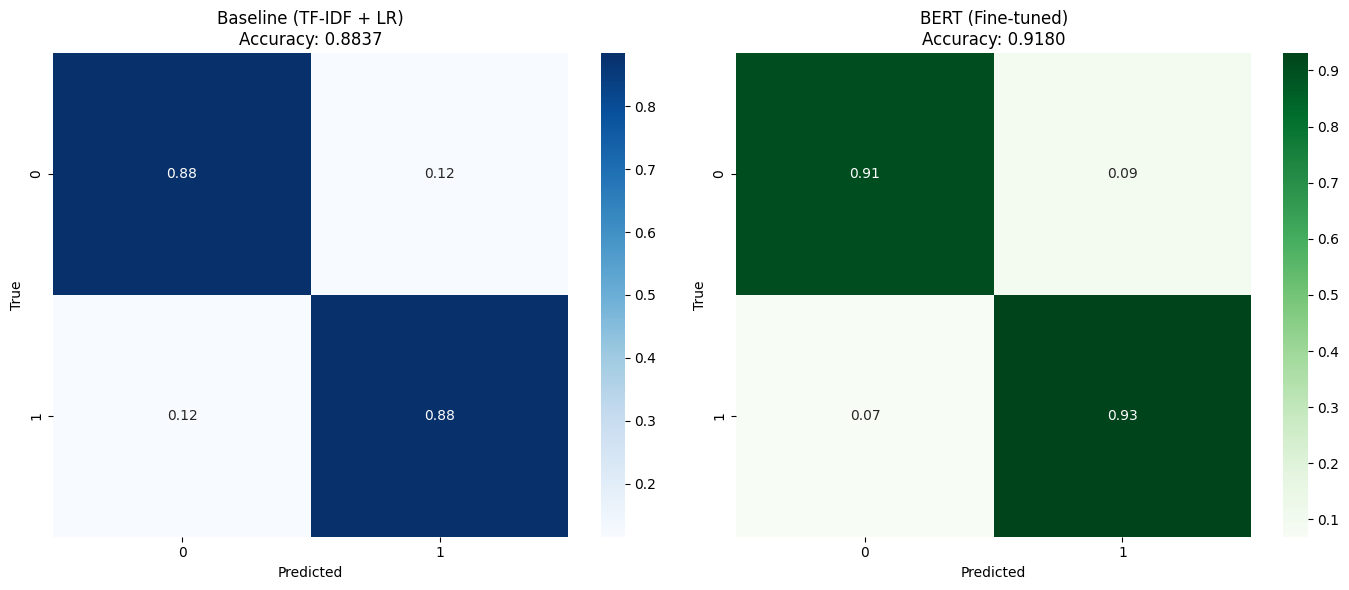

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Baseline Confusion Matrix
cm_baseline = confusion_matrix(test_labels, y_pred_baseline)
cm_baseline_norm = cm_baseline.astype('float') / cm_baseline.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_baseline_norm, annot=True, fmt='.2f', ax=ax[0], cmap='Blues')
ax[0].set_title(f'Baseline (TF-IDF + LR)\nAccuracy: {accuracy_baseline:.4f}')
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('True')

# BERT Confusion Matrix
cm_bert = confusion_matrix(small_test_dataset['label'], preds)
cm_bert_norm = cm_bert.astype('float') / cm_bert.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_bert_norm, annot=True, fmt='.2f', ax=ax[1], cmap='Greens')
ax[1].set_title(f'BERT (Fine-tuned)\nAccuracy: {accuracy_bert:.4f}')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Ответы на вопросы

### 1. Зачем нужен positional encoding?
В архитектуре Transformer нет рекуррентности (как в RNN) или сверток (как в CNN), поэтому модель не воспринимает порядок токенов в последовательности "из коробки". Positional encoding добавляет к эмбеддингам токенов информацию об их позиции в предложении, чтобы модель могла различать, например, "кот съел мышь" и "мышь съела кота".

### 2. В чём отличие encoder-only и decoder-only моделей?

Encoder-only (например, BERT): Используют только энкодер трансформера. Имеют двунаправленное внимание (видят весь контекст слева и справа). Хороши для задач понимания текста (классификация, NER, QA).

Decoder-only (например, GPT): Используют только декодер. Имеют маскированное внимание (видят только контекст слева). Хороши для генерации текста (next token prediction).

### 3. Почему трансформеры лучше RNN в NLP?

Параллелизация: RNN обрабатывают токены последовательно (t, затем t+1), что медленно. Трансформеры обрабатывают всю последовательность сразу, эффективно используя GPU.

Длинные зависимости: В RNN градиенты затухают на длинных последовательностях. Механизм Self-Attention в трансформерах позволяет напрямую связывать любые два слова в предложении, независимо от расстояния между ними.